<a href="https://colab.research.google.com/github/Jpablo179804/MineriaDatos/blob/main/Parcial2/exQuizz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Quizz Parcial 2

In [8]:
import pandas as pd
import io
from google.colab import files

# 1. Cargar el archivo en Google Colab
print("Por favor, sube el archivo 'munsell-array-fixed-choice.csv':")
uploaded = files.upload()

# 2. Obtener el nombre del archivo subido dinámicamente
nombre_archivo = list(uploaded.keys())[0]

# 3. Leer el dataset con Pandas usando io.BytesIO
df = pd.read_csv(io.BytesIO(uploaded[nombre_archivo]))

print("\n--- Resultados del Análisis ---")

# Pregunta 1: ¿Cuántos colores diferentes hay en el idioma Tsimane?
colores_unicos_tsimane = df['tsimane_color'].nunique()
print(f"1. Cantidad de colores diferentes en Tsimane: {colores_unicos_tsimane}")

# Pregunta 2: ¿Cuál es el color más común en Tsimane?
color_mas_comun = df['tsimane_color'].mode()[0]
print(f"2. El color más común en Tsimane es: {color_mas_comun}")

# Pregunta 3: ¿Qué porcentaje de los colores en el Munsell array son descritos como "blanco" en Español?
total_colores = len(df)
cantidad_blancos = len(df[df['spanish_color'] == 'white'])
porcentaje_blanco = (cantidad_blancos / total_colores) * 100
print(f"3. Porcentaje de colores descritos como 'blanco' en Español: {porcentaje_blanco:.2f}%")

Por favor, sube el archivo 'munsell-array-fixed-choice.csv':


Saving munsell-array-fixed-choice.csv to munsell-array-fixed-choice (3).csv

--- Resultados del Análisis ---
1. Cantidad de colores diferentes en Tsimane: 8
2. El color más común en Tsimane es: green
3. Porcentaje de colores descritos como 'blanco' en Español: 7.50%


Subir archivo:


Saving munsell-array-fixed-choice.csv to munsell-array-fixed-choice (6).csv


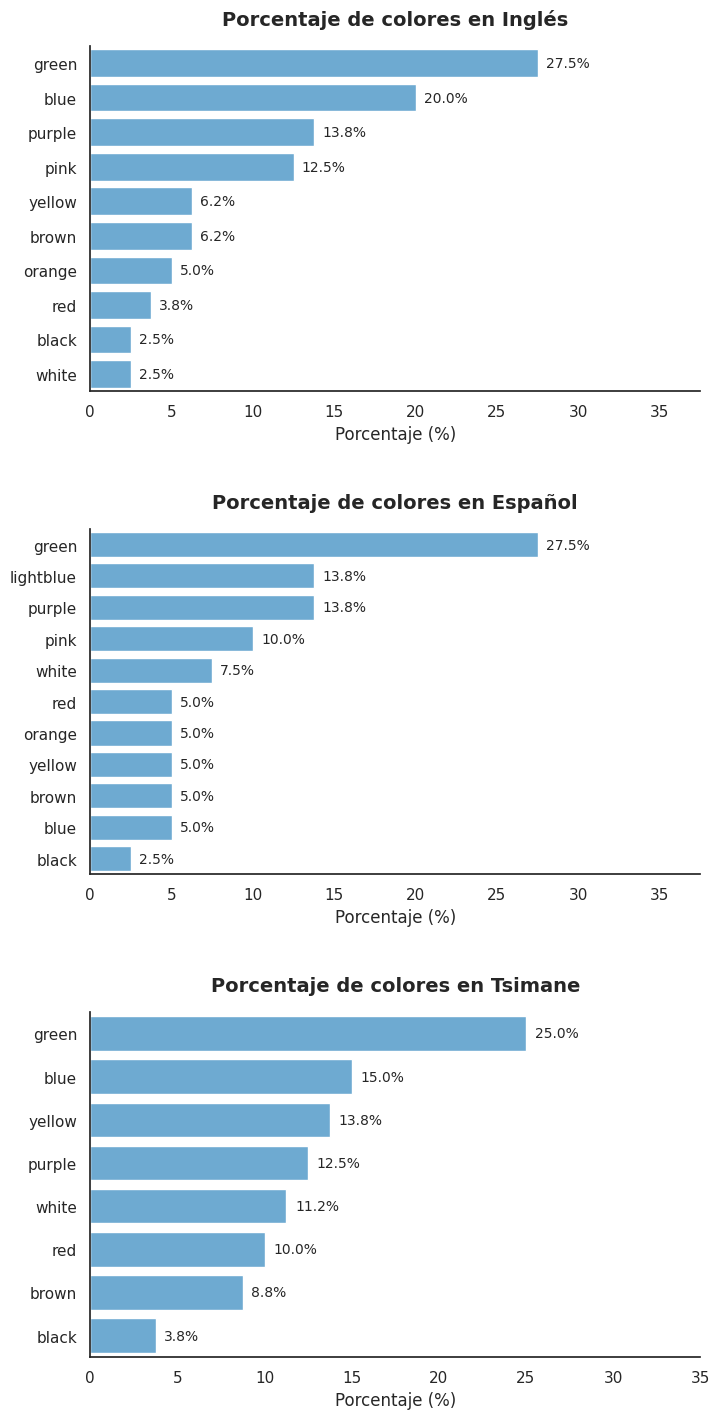

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files

print("Subir archivo:")
uploaded = files.upload()

nombre_archivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nombre_archivo]))
sns.set_theme(style="white")

def graficar_porcentajes_sencillos(dataframe, columna, titulo, ax):
    pct = (dataframe[columna].value_counts(normalize=True) * 100).reset_index()
    pct.columns = ['Color', 'Porcentaje']

    pct = pct.sort_values(by='Porcentaje', ascending=False)

    sns.barplot(data=pct, x='Porcentaje', y='Color', ax=ax, color='#5DADE2')

    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Porcentaje (%)', fontsize=12)
    ax.set_ylabel('')

    ax.set_xlim(0, pct['Porcentaje'].max() + 10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(width + 0.5,
                    p.get_y() + p.get_height() / 2,
                    f'{width:.1f}%',
                    ha="left",
                    va="center",
                    fontsize=10)

fig, axes = plt.subplots(3, 1, figsize=(8, 15))
graficar_porcentajes_sencillos(df, 'english_color', 'Porcentaje de colores en Inglés', axes[0])
graficar_porcentajes_sencillos(df, 'spanish_color', 'Porcentaje de colores en Español', axes[1])
graficar_porcentajes_sencillos(df, 'tsimane_color', 'Porcentaje de colores en Tsimane', axes[2])

plt.tight_layout(pad=3.0)
plt.show()

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from sklearn.metrics import normalized_mutual_info_score
import io
from google.colab import files
file_path = 'munsell-array-fixed-choice.csv'
df = pd.read_csv(file_path)

def visualizar_correlacion_munsell(df, lang1_col, lang2_col, label1, label2):
    """
    Crea una visualización de la cuadrícula de Munsell comparando dos idiomas.
    """
    # Configuración de la figura (basada en el formato de 20x8 del archivo)
    fig, ax = plt.subplots(figsize=(16, 7))

    # Límites de los ejes (Hue 1-20, Lightness 1-8)
    ax.set_xlim(0.5, 20.5)
    ax.set_ylim(0.5, 8.5)

    # Formato de los ejes (Números solicitados)
    ax.set_xticks(np.arange(1, 21, 1))
    ax.set_yticks(np.arange(1, 9, 1))
    ax.set_xlabel('Hue (Eje X)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Lightness (Eje Y)', fontsize=12, fontweight='bold')

    # Título y cálculo de "Correlación" (usando Información Mutua Normalizada para categorías)
    correlation_val = normalized_mutual_info_score(df[lang1_col], df[lang2_col])
    agreement_rate = (df[lang1_col] == df[lang2_col]).mean()

    ax.set_title(f"Correlación {label1} - {label2}\n"
                 f"Índice de Acuerdo: {agreement_rate:.1%} | NMI: {correlation_val:.3f}",
                 fontsize=15, fontweight='bold', pad=20)

    # Dibujar cada celda
    for _, row in df.iterrows():
        hx = row['x']
        ly = row['y']
        color_hex = row['tile_hex']

        # Determinar si hay acuerdo entre los dos idiomas
        match = (row[lang1_col] == row[lang2_col])

        # Color de fondo de la celda: Gris oscuro si coinciden, blanco si no.
        # Esto resalta la "correlación" espacial.
        bg_color = '#333333' if match else '#F0F0F0'

        # Dibujar el fondo de la celda
        rect_bg = patches.Rectangle((hx - 0.5, ly - 0.5), 1, 1,
                                    linewidth=0.5, edgecolor='black', facecolor=bg_color)
        ax.add_patch(rect_bg)

        # Dibujar la ficha de color (el color dentro)
        # La hacemos un poco más pequeña para que se vea el marco de correlación
        rect_color = patches.Rectangle((hx - 0.35, ly - 0.35), 0.7, 0.7,
                                       linewidth=0, facecolor=color_hex)
        ax.add_patch(rect_color)

    # Ajustes estéticos finales
    ax.set_aspect('equal')
    ax.grid(False)
    plt.tight_layout()

    # Guardar y mostrar
    plt

In [19]:
spanish_df = df['spanish_color'].value_counts().reset_index()

In [20]:
spanish_df['sp_color_percentage'] = spanish_df['count_es'] / spanish_df['count_es'].sum() * 100

KeyError: 'count_es'

In [21]:
corr_ing_esp = pd.merge(english_df, spanish_df, left_on='english_color', right_on='spanish_color', how='inner')

NameError: name 'english_df' is not defined